# Chapter 1: Introduction to Differential Equations
## Complete Instructor Interactive Notebook

This notebook combines Sections 1.1–1.3 into one continuous classroom sequence.

**Classroom use:** run the setup cell once, then proceed from top to bottom.  
Every student-facing problem with a prepared solution uses a **Reveal solution** or **Reveal discussion** button.

In [ ]:
# Run this setup cell once at the beginning of class.
import base64
import importlib.util
import platform
import sys

_REQUIRED = ["numpy", "matplotlib", "scipy", "sympy", "ipywidgets"]
_missing = [name for name in _REQUIRED if importlib.util.find_spec(name) is None]

print(f"Python {sys.version.split()[0]} on {platform.system()}")
if _missing:
    print("Missing package(s):", ", ".join(_missing))
    print("For the full interactive experience, install them from the project folder:")
    print("python -m pip install -r requirements.txt")
else:
    print("Notebook environment is ready.")

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from scipy.integrate import solve_ivp
from IPython.display import display, Markdown, clear_output

try:
    import ipywidgets as widgets
    from ipywidgets import (
        Button, ToggleButton, Output, VBox, HBox, Layout,
        HTML, HTMLMath, FloatSlider, IntSlider, interact
    )
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False

    # Fallback objects allow the mathematical notebooks to execute even
    # before ipywidgets is installed.  Buttons/sliders become active after
    # installing requirements.txt and restarting the kernel.
    def FloatSlider(*args, value=0.0, **kwargs):
        return value

    def IntSlider(*args, value=0, **kwargs):
        return value

    def interact(function, **kwargs):
        values = {}
        for key, obj in kwargs.items():
            values[key] = getattr(obj, "value", obj)
        function(**values)
        return None

plt.rcParams["figure.figsize"] = (9, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

def reveal_button_b64(encoded_answer, label="Reveal solution", style="success"):
    """Display a toggle button whose answer stays hidden until clicked."""
    if not WIDGETS_AVAILABLE:
        display(Markdown(
            "**Interactive reveal button unavailable.** "
            "Install `ipywidgets` with `python -m pip install -r requirements.txt`, "
            "restart the kernel, and run this cell again."
        ))
        return

    button = ToggleButton(
        value=False,
        description=label,
        button_style=style,
        icon="eye",
        layout=Layout(width="180px")
    )
    answer_out = Output(layout=Layout(
        border="1px solid #dddddd",
        padding="8px",
        width="98%"
    ))

    def _toggle(change):
        with answer_out:
            clear_output()
            if change["new"]:
                answer = base64.b64decode(encoded_answer).decode("utf-8")
                display(Markdown(answer))
                button.description = "Hide solution"
                button.icon = "eye-slash"
            else:
                button.description = label
                button.icon = "eye"

    button.observe(_toggle, names="value")
    display(VBox([button, answer_out]))

def classification_cards(items):
    """
    Large projected equation area with a reveal/hide button beside each item.
    items = [(equation_latex, answer_b64), ...]
    """
    if not WIDGETS_AVAILABLE:
        display(Markdown(
            "**Interactive classification buttons require `ipywidgets`.** "
            "Install `requirements.txt` and restart the kernel."
        ))
        for i, (equation_latex, _) in enumerate(items, start=1):
            display(Markdown(f"### Problem {i}\n\n$$\n{equation_latex}\n$$"))
        return

    cards = []

    def make_one(index, equation_latex, encoded_answer):
        eq = HTMLMath(
            value=(
                "<div style='font-size:24px; font-weight:600; "
                "white-space:nowrap; overflow-x:auto; padding:12px 10px;'>"
                f"${equation_latex}$"
                "</div>"
            ),
            layout=Layout(width="820px", min_width="680px")
        )
        button = ToggleButton(
            value=False,
            description=f"Reveal #{index}",
            button_style="info",
            icon="eye",
            layout=Layout(width="160px")
        )
        out = Output(layout=Layout(
            border="1px solid #d9e2f3",
            padding="7px",
            width="980px"
        ))

        def _toggle(change):
            with out:
                clear_output()
                if change["new"]:
                    answer = base64.b64decode(encoded_answer).decode("utf-8")
                    display(Markdown(answer))
                    button.description = f"Hide #{index}"
                    button.icon = "eye-slash"
                else:
                    button.description = f"Reveal #{index}"
                    button.icon = "eye"

        button.observe(_toggle, names="value")
        row = HBox(
            [eq, button],
            layout=Layout(width="1000px", align_items="center")
        )
        return VBox([row, out], layout=Layout(margin="0 0 12px 0"))

    for i, (equation_latex, answer_encoded) in enumerate(items, start=1):
        cards.append(make_one(i, equation_latex, answer_encoded))
    display(VBox(cards))

Python 3.13.15 on Linux
Notebook environment is ready.


In [ ]:
import base64
import ipywidgets as widgets

from IPython.display import display, Math, Markdown, clear_output
from ipywidgets import ToggleButton, Output, VBox, HBox, Layout


def _make_reveal_problem(number, equation_latex, encoded_answer):

    # Large equation area
    equation_out = Output(
        layout=Layout(
            width="780px",
            min_width="700px",
            padding="12px 18px"
        )
    )

    with equation_out:
        display(Math(r"\displaystyle " + equation_latex))

    # Reveal button
    button = ToggleButton(
        value=False,
        description=f"Reveal #{number}",
        button_style="info",
        icon="eye",
        layout=Layout(
            width="160px",
            height="42px"
        )
    )

    # Hidden answer area
    answer_out = Output(
        layout=Layout(
            width="980px",
            border="1px solid #dddddd",
            padding="10px 14px"
        )
    )

    def toggle_answer(change):

        with answer_out:
            clear_output()

            if change["new"]:

                answer = base64.b64decode(
                    encoded_answer
                ).decode("utf-8")

                display(Markdown(answer))

                button.description = f"Hide #{number}"
                button.icon = "eye-slash"

            else:

                button.description = f"Reveal #{number}"
                button.icon = "eye"

    button.observe(toggle_answer, names="value")

    row = HBox(
        [equation_out, button],
        layout=Layout(
            width="1000px",
            align_items="center",
            justify_content="space-between"
        )
    )

    display(
        VBox(
            [row, answer_out],
            layout=Layout(
                width="1000px",
                margin="0 0 18px 0"
            )
        )
    )


def show_classification_problems():

    problems = [

        (
            r"y'+(1+x^2)y=e^{-x}",

            "IyMjIFNvbHV0aW9uIDEKClRoaXMgaXMgYSAqKmZpcnN0LW9yZGVyIGxpbmVhciBPREUqKi4KClRoZSBjb2VmZmljaWVudCAkMSt4XjIkIGFuZCB0aGUgZm9yY2luZyAkZV57LXh9JCBhcmUgY29udGludW91cyBmb3IgZXZlcnkgcmVhbCAkeCQuCgpUaGVyZWZvcmUgdGhlIGxhcmdlc3QgcmVhbCBpbnRlcnZhbCBpcwoKJCQKKC1caW5mdHksXGluZnR5KS4KJCQ="
        ),

        (
            r"(x-2)y''+3y'-y=0",

            "IyMjIFNvbHV0aW9uIDIKClRoaXMgaXMgYSAqKnNlY29uZC1vcmRlciBsaW5lYXIgT0RFKiouCgpUbyBwdXQgaXQgaW4gc3RhbmRhcmQgZm9ybSwgZGl2aWRlIGJ5ICR4LTIkOgoKJCQKeScnK1xmcmFjezN9e3gtMn15Jy1cZnJhY3sxfXt4LTJ9eT0wLgokJAoKVGhlIGNvZWZmaWNpZW50cyBhcmUgdW5kZWZpbmVkIGF0ICR4PTIkLgoKVGh1cyB0aGUgbGFyZ2VzdCByZWFsIGludGVydmFscyBhcmUKCiQkCigtXGluZnR5LDIpClxxcXVhZFx0ZXh0e2FuZH1ccXF1YWQKKDIsXGluZnR5KS4KJCQ="
        ),

        (
            r"y''+y^2=\cos x",

            "IyMjIFNvbHV0aW9uIDMKClRoaXMgaXMgYSAqKnNlY29uZC1vcmRlciBub25saW5lYXIgT0RFKiogYmVjYXVzZSBvZiB0aGUgdGVybSAkeV4yJC4KClRoZSBlcXVhdGlvbiBpdHNlbGYgaGFzIG5vIHNpbmd1bGFyIGNvZWZmaWNpZW50IGluICR4JCwgc28gaXQgaXMgZGVmaW5lZCBmb3IgZXZlcnkgcmVhbCAkeCQuCgpGb3IgY2xhc3NpZmljYXRpb24gcHVycG9zZXMsIHRoZSBuYXR1cmFsIHJlYWwgZG9tYWluIGlzCgokJAooLVxpbmZ0eSxcaW5mdHkpLgokJA=="
        ),

        (
            r"\frac{dy}{dx}=\frac{x+y}{x-1}",

            "IyMjIFNvbHV0aW9uIDQKCkFsdGhvdWdoIGl0IGlzIHdyaXR0ZW4gYXMgYSBxdW90aWVudCwgaXQgaXMgYWN0dWFsbHkgKipsaW5lYXIqKiBpbiAkeSQ6CgokJAp5Jy1cZnJhY3sxfXt4LTF9eT1cZnJhY3t4fXt4LTF9LgokJAoKSGVuY2UgaXQgaXMgYSAqKmZpcnN0LW9yZGVyIGxpbmVhciBPREUqKi4KClRoZSBzaW5ndWxhciBwb2ludCBpcyAkeD0xJCwgc28gdGhlIGxhcmdlc3QgcmVhbCBpbnRlcnZhbHMgYXJlCgokJAooLVxpbmZ0eSwxKQpccXF1YWRcdGV4dHthbmR9XHFxdWFkCigxLFxpbmZ0eSkuCiQk"
        )

    ]

    for number, (equation, answer) in enumerate(
        problems,
        start=1
    ):

        _make_reveal_problem(
            number,
            equation,
            answer
        )

# Section 1.1: Definitions, Classification, and Solutions

## 1. What is a differential equation?

A **differential equation** is an equation involving an unknown function and one or more of its derivatives.

For example,

$$
y' = 4x-y
$$

contains the unknown function $y(x)$ and its first derivative $y'(x)$.

The derivative represents a **rate of change**. A differential equation therefore prescribes how that rate must depend on the current state, the independent variable, or other quantities.

Examples:

$$
y'=4x-y,
$$

$$
y''+3y'-2y=\sin x,
$$

and, for a system,

$$
x'=y,\qquad y'=-x.
$$

## 2. Visual interpretation: the differential equation is a rate rule

Consider the straightforward initial-value example

$$
\boxed{y'=2t-y,\qquad y(0)=1.}
$$

Here

- $t$ is the independent variable,
- $y(t)$ is the state,
- $y'(t)$ is the instantaneous rate of change,
- and the rule
  $$
  y'=2t-y
  $$
  tells us how the rate depends on **both time and the current state**.

At a point $(t,y)$, the rate is obtained by direct substitution:

$$
\renewcommand{\arraystretch}{1.6}
\begin{array}{|c|c|c|}
\hline
\textbf{Point}
&
\textbf{Rate } y'=2t-y
&
\textbf{Interpretation}
\\
\hline
(0,0) & 0 & \text{locally flat} \\
\hline
(1,0) & 2 & \text{increasing rapidly} \\
\hline
(1,3) & -1 & \text{decreasing} \\
\hline
(2,4) & 0 & \text{locally flat} \\
\hline
\end{array}
$$

The line

$$
y=2t
$$

is the set of points where the instantaneous rate is zero.

### Solve the example completely

Rewrite the equation as

$$
y'+y=2t.
$$

The integrating factor is

$$
\mu(t)=e^{\int 1\,dt}=e^t.
$$

Multiplying by $e^t$ gives

$$
e^ty'+e^ty=2te^t,
$$

so

$$
\frac{d}{dt}\left(e^ty\right)=2te^t.
$$

Integrating,

$$
e^ty=2e^t(t-1)+C.
$$

Therefore

$$
y(t)=2t-2+Ce^{-t}.
$$

Using $y(0)=1$,

$$
1=-2+C,
$$

hence

$$
C=3.
$$

The solution is

$$
\boxed{y(t)=2t-2+3e^{-t}.}
$$

The simulation below connects the rate rule $2t-y$ with the solution curve.

In [ ]:
def rate_rule_visual(y0=1.0):
    # Rate landscape
    t_vals = np.linspace(0, 4, 31)
    y_vals = np.linspace(-1, 8, 31)
    T, Y = np.meshgrid(t_vals, y_vals)
    F = 2*T - Y

    # Direction segments normalized for display
    U = np.ones_like(F)
    V = F.copy()
    N = np.sqrt(U**2 + V**2)
    U, V = U/N, V/N

    # Exact solution for arbitrary y(0)=y0
    tt = np.linspace(0, 4, 500)
    C = y0 + 2
    yy = 2*tt - 2 + C*np.exp(-tt)
    rate_along_solution = 2*tt - yy

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

    # Left: colorful rate map
    heat = axes[0].contourf(T, Y, F, levels=30, cmap="coolwarm")
    axes[0].quiver(T[::2, ::2], Y[::2, ::2],
                   U[::2, ::2], V[::2, ::2],
                   color="black", alpha=0.55, pivot="mid")
    axes[0].plot(tt, yy, color="gold", linewidth=3,
                 label=fr"solution through $(0,{y0:g})$")
    axes[0].plot(tt, 2*tt, color="white", linewidth=2,
                 linestyle="--", label=r"$y=2t$ gives $y'=0$")
    axes[0].set_xlabel("time $t$")
    axes[0].set_ylabel("state $y$")
    axes[0].set_title(r"Rate map: color represents $y'=2t-y$")
    axes[0].legend(loc="upper left")
    fig.colorbar(heat, ax=axes[0], label="instantaneous rate")

    # Right: solution colored by instantaneous rate
    sc = axes[1].scatter(tt, yy, c=rate_along_solution,
                         cmap="viridis", s=18)
    axes[1].plot(tt, yy, color="black", alpha=0.45)
    axes[1].scatter([0], [y0], s=90, color="crimson",
                    label="initial condition")
    axes[1].set_xlabel("time $t$")
    axes[1].set_ylabel("$y(t)$")
    axes[1].set_title("The same rate rule generates the solution curve")
    axes[1].legend()
    fig.colorbar(sc, ax=axes[1], label=r"$y'(t)$ along the solution")

    plt.tight_layout()
    plt.show()

interact(
    rate_rule_visual,
    y0=FloatSlider(min=-0.5, max=4.0, step=0.25, value=1.0,
                   description="y(0)")
);

interactive(children=(FloatSlider(value=1.0, description='y(0)', max=4.0, min=-0.5, step=0.25), Output()), _do…

### Interpretation

The picture encodes one central idea:

> A differential equation does not directly give the graph of the solution.  
> It gives a **local rate rule**. The solution curve is the curve whose slope obeys that rule at every point.

For $y'=2t-y$:

- below the line $y=2t$, we have $y'>0$, so solutions tend to rise;
- above the line $y=2t$, we have $y'<0$, so solutions tend to fall;
- on $y=2t$, the instantaneous slope is zero.

We will formalize this geometric idea using **direction fields** in Section 1.2.

## 3. Classification foundations

Before classifying an equation, we need the vocabulary.

### 3.1 ODE versus PDE

An **ordinary differential equation (ODE)** involves derivatives with respect to one independent variable.

Example:

$$
y''+xy'-y=0.
$$

A **partial differential equation (PDE)** involves partial derivatives with respect to two or more independent variables.

Example:

$$
u_t=3u_{xx}.
$$

### 3.2 Order

The **order** is the order of the highest derivative appearing in the equation.

Examples:

$$
y'+y=0
$$

is first order, while

$$
y'''+xy'=e^x
$$

is third order.

### 3.3 Linear versus nonlinear

An $n$th-order ODE is **linear** if it can be written as

$$
a_n(x)y^{(n)}
+a_{n-1}(x)y^{(n-1)}
+\cdots
+a_1(x)y'
+a_0(x)y
=
g(x),
$$

where the coefficients $a_j(x)$ and forcing $g(x)$ depend only on the independent variable.

In a linear equation:

- $y$ and its derivatives occur only to the first power;
- products such as $yy'$ do not occur;
- nonlinear functions such as $\sin y$, $e^y$, or $(y')^2$ do not occur.

Examples:

$$
(1+x^2)y''+xy'-4y=e^x
$$

is linear.

By contrast,

$$
y''+y^2=0
$$

is nonlinear because of $y^2$, and

$$
y''+\sin y=0
$$

is nonlinear because of $\sin y$.

## 4. Differential form and normal form

A first-order ODE may be written in **differential form**

$$
M(x,y)\,dx+N(x,y)\,dy=0.
$$

Since

$$
dy=y'\,dx,
$$

we may sometimes solve for $y'$ and obtain **normal form**

$$
y'=f(x,y).
$$

Example:

$$
(2x-y)\,dx+(1+x)\,dy=0.
$$

Divide by $dx$:

$$
2x-y+(1+x)y'=0.
$$

Therefore

$$
y'=\frac{y-2x}{1+x},
\qquad x\ne-1.
$$

The excluded point $x=-1$ is important when we discuss intervals of definition.

## 5. Interval of definition

A solution is always attached to an **interval** on which

1. the solution formula is defined and differentiable, and
2. the differential equation itself is defined.

For example,

$$
(x-2)y'+y=0
$$

can be written as

$$
y'+\frac{1}{x-2}y=0.
$$

The coefficient $1/(x-2)$ is undefined at $x=2$.

Therefore the largest real intervals on which this equation has continuous coefficients are

$$
(-\infty,2)
\qquad\text{and}\qquad
(2,\infty).
$$

A solution cannot be treated as a single classical solution on an interval that crosses $x=2$.

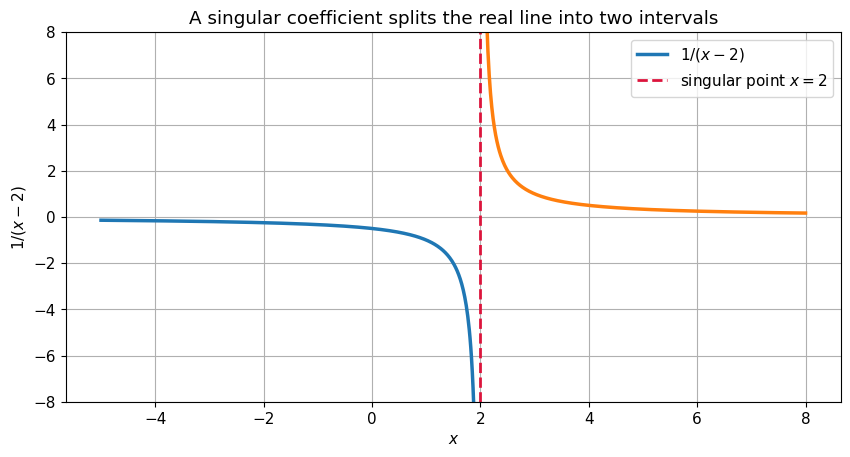

In [ ]:
x_left = np.linspace(-5, 1.92, 500)
x_right = np.linspace(2.08, 8, 500)

plt.figure(figsize=(10, 4.8))
plt.plot(x_left, 1/(x_left-2), linewidth=2.5, label=r"$1/(x-2)$")
plt.plot(x_right, 1/(x_right-2), linewidth=2.5)
plt.axvline(2, color="crimson", linestyle="--", linewidth=2,
            label=r"singular point $x=2$")
plt.ylim(-8, 8)
plt.xlabel("$x$")
plt.ylabel(r"$1/(x-2)$")
plt.title("A singular coefficient splits the real line into two intervals")
plt.legend()
plt.show()

## 6. In-class classification

Now that the definitions of **type, order, linearity, and interval of definition** have been introduced, classify each equation.

For every equation, determine:

1. ODE or PDE,
2. order,
3. linear or nonlinear,
4. largest real interval(s) on which the equation is defined.

Run the next cell to display the large equations and reveal buttons.  
The solution stays hidden until you click the corresponding button.

In [ ]:
show_classification_problems()

## 7. Verifying an explicit solution

Consider

$$
y'+2y=x.
$$

A proposed one-parameter family is

$$
y(x)=Ce^{-2x}+\frac{x}{2}-\frac14.
$$

To verify a proposed solution:

1. differentiate the proposed function;
2. substitute $y$ and its derivatives into the differential equation;
3. simplify;
4. confirm that the resulting identity is true on the interval of interest.

Differentiate:

$$
y'=-2Ce^{-2x}+\frac12.
$$

Then

$$
y'+2y
=
\left(-2Ce^{-2x}+\frac12\right)
+
2\left(Ce^{-2x}+\frac{x}{2}-\frac14\right)
=
x.
$$

Therefore every member of the family is a solution.

In [ ]:
x, C = sp.symbols("x C", real=True)
y = C*sp.exp(-2*x) + x/2 - sp.Rational(1, 4)
residual = sp.simplify(sp.diff(y, x) + 2*y - x)

print("Proposed family:")
display(y)
print("Residual after substitution:")
display(residual)

Proposed family:


C*exp(-2*x) + x/2 - 1/4

Residual after substitution:


0

### Classroom Checkpoint — Verification

Does

$$
y=x^2+1
$$

solve

$$
y'=2x+y-x^2-1?
$$

Work by substitution before revealing the solution.

In [ ]:
reveal_button_b64(
    "IyMjIFNvbHV0aW9uCgpEaWZmZXJlbnRpYXRlOgoKJCQKeSc9MnguCiQkCgpUaGUgcmlnaHQtaGFuZCBzaWRlIGlzCgokJAoyeCt5LXheMi0xCj0KMngrKHheMisxKS14XjItMQo9CjJ4LgokJAoKQm90aCBzaWRlcyBhZ3JlZSwgc28KCiQkClxib3hlZHt5PXheMisxfQokJAoKaXMgYSBzb2x1dGlvbiBmb3IgZXZlcnkgcmVhbCAkeCQu"
)

## 8. A family of solutions

Changing the constant $C$ in

$$
y=Ce^{-2x}+\frac{x}{2}-\frac14
$$

selects a different member of the solution family.

The differential equation determines the whole family.  
An initial condition, introduced in Section 1.2, will select one member.

In [ ]:
def plot_solution_family(C_selected=1.0):
    x_vals = np.linspace(-1.0, 2.5, 500)

    plt.figure(figsize=(10, 5))
    for c in [-2, -1, 0, 1, 2]:
        y_vals = c*np.exp(-2*x_vals) + x_vals/2 - 0.25
        plt.plot(x_vals, y_vals, alpha=0.45)

    y_sel = C_selected*np.exp(-2*x_vals) + x_vals/2 - 0.25
    plt.plot(x_vals, y_sel, linewidth=3.2, color="crimson",
             label=fr"selected $C={C_selected:.2f}$")
    plt.xlabel("$x$")
    plt.ylabel("$y$")
    plt.title("One differential equation, many solution curves")
    plt.legend()
    plt.ylim(-5, 5)
    plt.show()

interact(
    plot_solution_family,
    C_selected=FloatSlider(min=-2, max=2, step=0.25, value=1.0,
                           description="C")
);

interactive(children=(FloatSlider(value=1.0, description='C', max=2.0, min=-2.0, step=0.25), Output()), _dom_c…

## 9. Explicit and implicit solutions

An **explicit solution** has the form

$$
y=\phi(x).
$$

An **implicit solution** is a relation

$$
G(x,y)=0
$$

that may define one or more branches.

Example:

$$
x^2+2y^2=18.
$$

Solving for $y$ gives

$$
y=\pm\sqrt{\frac{18-x^2}{2}}.
$$

Thus one implicit relation produces two explicit branches.

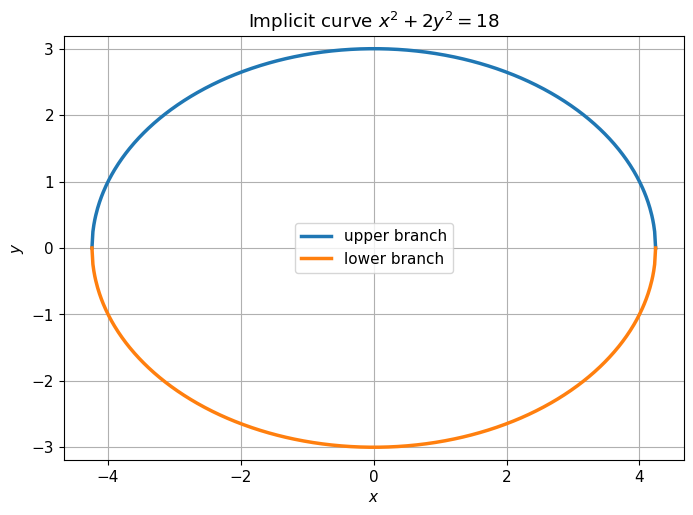

In [ ]:
x_vals = np.linspace(-np.sqrt(18), np.sqrt(18), 600)
inside = (18 - x_vals**2)/2
y_upper = np.sqrt(np.maximum(inside, 0))
y_lower = -y_upper

plt.figure(figsize=(8, 5.5))
plt.plot(x_vals, y_upper, linewidth=2.5, label="upper branch")
plt.plot(x_vals, y_lower, linewidth=2.5, label="lower branch")
plt.axis("equal")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title(r"Implicit curve $x^2+2y^2=18$")
plt.legend()
plt.show()

## 10. Systems of differential equations

A system contains two or more unknown functions.

For example,

$$
x'=y,
\qquad
y'=-x.
$$

Differentiate the first equation:

$$
x''=y'.
$$

Since $y'=-x$,

$$
x''+x=0.
$$

Thus the two-dimensional first-order system is equivalent to the familiar harmonic oscillator.

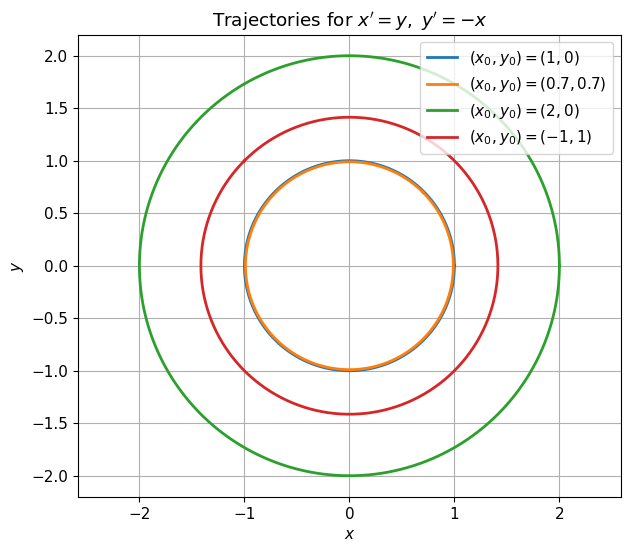

In [ ]:
def oscillator(t, z):
    x, y = z
    return [y, -x]

initial_states = [(1, 0), (0.7, 0.7), (2, 0), (-1, 1)]
t_eval = np.linspace(0, 2*np.pi, 600)

plt.figure(figsize=(7, 6))
for z0 in initial_states:
    sol = solve_ivp(oscillator, (0, 2*np.pi), z0, t_eval=t_eval,
                    rtol=1e-9, atol=1e-11)
    plt.plot(sol.y[0], sol.y[1], linewidth=2,
             label=fr"$(x_0,y_0)={z0}$")

plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title(r"Trajectories for $x'=y,\;y'=-x$")
plt.axis("equal")
plt.legend()
plt.show()

## Classroom Checkpoint — Exit Classification

Classify

$$
(1+t^2)y''+e^t y'+\sin(t)y=t^3.
$$

Determine:

1. the order,
2. whether it is linear,
3. the largest real interval,
4. how many arbitrary constants you would expect in the general solution of the corresponding second-order problem.

In [ ]:
reveal_button_b64(
    "IyMjIFNvbHV0aW9uCgpUaGUgaGlnaGVzdCBkZXJpdmF0aXZlIGlzICR5JyckLCBzbyB0aGUgZXF1YXRpb24gaXMgKipzZWNvbmQgb3JkZXIqKi4KCkl0IGlzICoqbGluZWFyKiogYmVjYXVzZSAkeSQsICR5JyQsIGFuZCAkeScnJCBvY2N1ciBvbmx5IHRvIHRoZSBmaXJzdCBwb3dlciBhbmQgdGhlaXIgY29lZmZpY2llbnRzIGRlcGVuZCBvbmx5IG9uICR0JC4KClNpbmNlCgokJAoxK3ReMj4wCiQkCgpmb3IgZXZlcnkgcmVhbCAkdCQsIGFsbCBjb2VmZmljaWVudHMgYXJlIGNvbnRpbnVvdXMgZm9yIGFsbCByZWFsICR0JC4KClRodXMgdGhlIGxhcmdlc3QgcmVhbCBpbnRlcnZhbCBpcwoKJCQKKC1caW5mdHksXGluZnR5KS4KJCQKCkEgc2Vjb25kLW9yZGVyIGdlbmVyYWwgc29sdXRpb24gbm9ybWFsbHkgY29udGFpbnMgKip0d28gYXJiaXRyYXJ5IGNvbnN0YW50cyoqLg=="
)


---

<div style='font-size:20px; font-weight:600;'>Continue to the next section when ready.</div>

# Section 1.2: Initial-Value Problems, Direction Fields, Existence, and Uniqueness

## 1. Initial-value problems

A differential equation usually has many solutions.  
An **initial condition** selects the solution that passes through specified data.

A first-order initial-value problem has the form

$$
y'=f(x,y),
\qquad
y(x_0)=y_0.
$$

Geometrically, we seek a solution curve that passes through the point

$$
(x_0,y_0).
$$

A second-order IVP requires two initial conditions, for example

$$
y''=F(x,y,y'),
\qquad
y(x_0)=y_0,
\qquad
y'(x_0)=v_0.
$$

The second condition specifies the initial slope as well as the initial position.

### Example 1: selecting one member of a first-order family

The family

$$
y=Ce^{x/2}
$$

solves

$$
y'=\frac12 y.
$$

Impose

$$
y(1)=4.
$$

Then

$$
4=Ce^{1/2},
$$

so

$$
C=4e^{-1/2}.
$$

Therefore the IVP solution is

$$
\boxed{y=4e^{(x-1)/2}}.
$$

In [ ]:
def first_order_ivp_picture(x0=1.0, y0=4.0):
    x_vals = np.linspace(-2, 4, 600)

    plt.figure(figsize=(10, 5.2))
    for C in [-4, -2, 0, 2, 4]:
        plt.plot(x_vals, C*np.exp(x_vals/2), alpha=0.35)

    C_selected = y0*np.exp(-x0/2)
    y_selected = C_selected*np.exp(x_vals/2)
    plt.plot(x_vals, y_selected, color="crimson", linewidth=3,
             label="solution selected by the initial condition")
    plt.scatter([x0], [y0], s=110, color="gold", edgecolor="black",
                zorder=5, label=fr"$(x_0,y_0)=({x0:.1f},{y0:.1f})$")
    plt.xlabel("$x$")
    plt.ylabel("$y$")
    plt.title("An initial condition selects one curve from a solution family")
    plt.legend()
    plt.show()

interact(
    first_order_ivp_picture,
    x0=FloatSlider(min=-1, max=2, step=0.25, value=1.0, description="$x_0$"),
    y0=FloatSlider(min=1, max=6, step=0.25, value=4.0, description="$y_0$")
);

interactive(children=(FloatSlider(value=1.0, description='$x_0$', max=2.0, min=-1.0, step=0.25), FloatSlider(v…

### Example 2: a second-order IVP

The family

$$
x(t)=c_1\cos(2t)+c_2\sin(2t)
$$

solves

$$
x''+4x=0.
$$

Suppose

$$
x(0)=1.5,
\qquad
x'(0)=-2.
$$

From

$$
x(0)=c_1,
$$

we obtain

$$
c_1=1.5.
$$

Differentiate:

$$
x'(t)
=
-2c_1\sin(2t)+2c_2\cos(2t).
$$

At $t=0$,

$$
x'(0)=2c_2=-2,
$$

so

$$
c_2=-1.
$$

Hence

$$
\boxed{x(t)=1.5\cos(2t)-\sin(2t)}.
$$

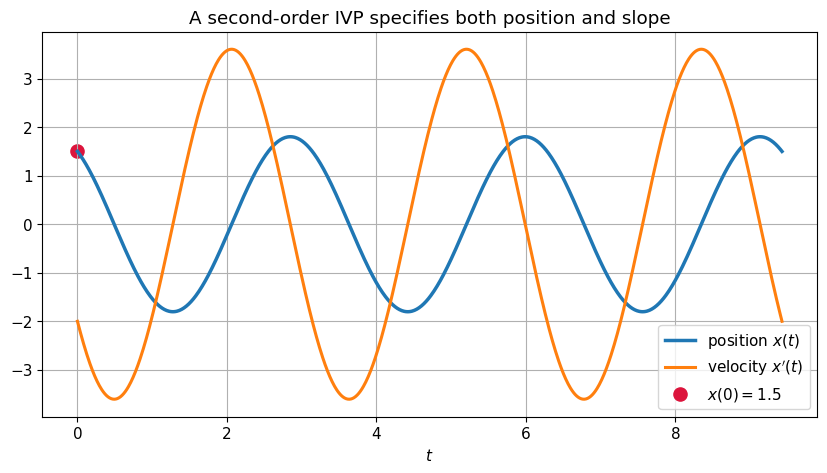

In [ ]:
t = np.linspace(0, 3*np.pi, 900)
position = 1.5*np.cos(2*t) - np.sin(2*t)
velocity = -3*np.sin(2*t) - 2*np.cos(2*t)

plt.figure(figsize=(10, 5))
plt.plot(t, position, linewidth=2.5, label="position $x(t)$")
plt.plot(t, velocity, linewidth=2.2, label="velocity $x'(t)$")
plt.scatter([0], [1.5], s=90, color="crimson", label="$x(0)=1.5$")
plt.xlabel("$t$")
plt.legend()
plt.title("A second-order IVP specifies both position and slope")
plt.show()

## 2. Direction fields: seeing the differential equation before solving it

For a first-order equation

$$
y'=f(x,y),
$$

the value $f(x,y)$ gives the slope that a solution must have when it passes through the point $(x,y)$.

A **direction field** (or slope field) is created by drawing a short line segment with slope

$$
f(x,y)
$$

at many points in the plane.

A solution curve must move through this field while remaining tangent to the local line segments.

### A first direction-field example

Consider

$$
\boxed{y'=x-y.}
$$

At several points,

$$
f(0,0)=0,
$$

$$
f(1,0)=1,
$$

$$
f(0,1)=-1,
$$

and

$$
f(1,1)=0.
$$

Thus

- the field is horizontal where $x-y=0$, or $y=x$;
- below $y=x$, the slope is positive;
- above $y=x$, the slope is negative.

For the IVP

$$
y'=x-y,
\qquad
y(0)=1,
$$

the exact solution is

$$
y=x-1+2e^{-x}.
$$

In [ ]:
def direction_field_example(y0=1.0):
    x_grid = np.linspace(-2, 4, 25)
    y_grid = np.linspace(-2, 4, 25)
    X, Y = np.meshgrid(x_grid, y_grid)

    S = X - Y
    U = np.ones_like(S)
    V = S.copy()
    N = np.sqrt(U**2 + V**2)
    U, V = U/N, V/N

    # solution through (0,y0)
    xx = np.linspace(-1.5, 4, 700)
    C = y0 + 1
    yy = xx - 1 + C*np.exp(-xx)

    plt.figure(figsize=(10, 6))
    field = plt.quiver(
        X, Y, U, V, S,
        cmap="coolwarm",
        pivot="mid",
        alpha=0.9
    )
    plt.plot(xx, yy, color="gold", linewidth=3,
             label=fr"solution through $(0,{y0:.1f})$")
    plt.plot(xx, xx, color="black", linestyle="--", linewidth=1.8,
             label=r"$y=x$: zero slope")
    plt.scatter([0], [y0], s=100, color="crimson", edgecolor="black", zorder=5)
    plt.xlim(-2, 4)
    plt.ylim(-2, 4)
    plt.xlabel("$x$")
    plt.ylabel("$y$")
    plt.title(r"Direction field for $y'=x-y$")
    plt.colorbar(field, label="slope $x-y$")
    plt.legend()
    plt.show()

interact(
    direction_field_example,
    y0=FloatSlider(min=-1.5, max=3.5, step=0.25, value=1.0,
                   description="$y(0)$")
);

interactive(children=(FloatSlider(value=1.0, description='$y(0)$', max=3.5, min=-1.5, step=0.25), Output()), _…

### What a direction field tells us

Even without solving the equation analytically, a direction field can suggest

- where solutions increase,
- where solutions decrease,
- where the slope is zero,
- whether nearby solution curves appear to move together or apart,
- and how an initial condition selects a particular trajectory.

The next question is deeper:

> Given an initial point, does a solution actually exist?  
> If it exists, is it the only one?

## 3. Existence: when can we expect at least one local solution?

Consider

$$
y'=f(x,y),
\qquad
y(x_0)=y_0.
$$

A fundamental local-existence principle is:

> If $f$ is continuous in a rectangle containing $(x_0,y_0)$, then at least one solution exists on some interval around $x_0$.

Continuity means that the slope rule does not suddenly jump or become undefined near the initial point.

However, continuity of $f$ by itself does **not** guarantee that the solution is unique.

## 4. A practical existence-and-uniqueness theorem

For classroom calculations, a common theorem is the following.

### Existence and Uniqueness Theorem

Consider

$$
y'=f(x,y),
\qquad
y(x_0)=y_0.
$$

Suppose there is a rectangle

$$
R:
\qquad
|x-x_0|\le a,
\qquad
|y-y_0|\le b,
$$

such that both

$$
f(x,y)
$$

and

$$
f_y(x,y)=\frac{\partial f}{\partial y}
$$

are continuous on $R$.

Then there exists an interval

$$
|x-x_0|\le h
$$

on which the IVP has a **unique solution**.

### Why are there two assumptions?

- Continuity of $f$ supports **existence**.
- Continuity of $f_y$ is a convenient sufficient condition for a **Lipschitz condition in $y$**, which supports **uniqueness**.

The theorem is local: it guarantees a solution near $x_0$, not automatically for every real $x$.

### Step-by-step interpretation of the theorem

Suppose the initial point is $(x_0,y_0)$.

**Step 1. Choose a rectangle around the initial point.**

$$
R=[x_0-a,x_0+a]\times[y_0-b,y_0+b].
$$

**Step 2. Check that $f$ is continuous on the rectangle.**

This prevents the slope rule from being undefined or discontinuous.

**Step 3. Check that $f_y$ is continuous on the rectangle.**

Because a continuous function on a closed bounded rectangle is bounded, there is some $L>0$ such that

$$
|f_y(x,y)|\le L.
$$

By the Mean Value Theorem in the $y$ variable,

$$
|f(x,y_1)-f(x,y_2)|
\le
L|y_1-y_2|.
$$

This is the local Lipschitz condition.

**Step 4. Restrict to a sufficiently short interval in $x$.**

If

$$
|f(x,y)|\le M
$$

on the rectangle, then choosing $h$ no larger than approximately

$$
\min\left(a,\frac{b}{M}\right)
$$

keeps the solution from leaving the rectangle immediately.

**Step 5. Conclude local existence and uniqueness.**

A solution exists through the initial point, and no second distinct solution can pass through the same point while the theorem applies.

In [ ]:
# Geometry of the theorem for f(x,y)=x-y
x0, y0 = 0.0, 1.0
a, b = 1.5, 1.25

x_grid = np.linspace(x0-a, x0+a, 21)
y_grid = np.linspace(y0-b, y0+b, 21)
X, Y = np.meshgrid(x_grid, y_grid)
S = X - Y

U = np.ones_like(S)
V = S.copy()
N = np.sqrt(U**2 + V**2)
U, V = U/N, V/N

xx = np.linspace(-1.4, 1.4, 500)
yy = xx - 1 + 2*np.exp(-xx)

fig, ax = plt.subplots(figsize=(9, 6))
q = ax.quiver(X, Y, U, V, S, cmap="coolwarm", pivot="mid")
rect = plt.Rectangle((x0-a, y0-b), 2*a, 2*b,
                     fill=False, linewidth=3, edgecolor="gold")
ax.add_patch(rect)
ax.plot(xx, yy, color="black", linewidth=2.7, label="solution through $(0,1)$")
ax.scatter([x0], [y0], s=110, color="crimson", zorder=5, label="initial point")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("Direction field inside a theorem rectangle")
ax.legend()
fig.colorbar(q, ax=ax, label="slope")
plt.show()

## 5. Why the theorem works: a proof sketch

A full proof belongs to a more advanced differential equations course, but the central ideas are accessible.

Start with

$$
y'=f(x,y),
\qquad
y(x_0)=y_0.
$$

Integrate from $x_0$ to $x$:

$$
\int_{x_0}^{x}y'(t)\,dt
=
\int_{x_0}^{x}f(t,y(t))\,dt.
$$

Using the Fundamental Theorem of Calculus,

$$
\boxed{
y(x)
=
y_0+\int_{x_0}^{x}f(t,y(t))\,dt.
}
$$

Thus solving the IVP is equivalent to finding a function that satisfies this **integral equation**.

### Picard iteration

Begin with a simple first guess

$$
y_0(x)=y_0.
$$

Then define recursively

$$
y_{n+1}(x)
=
y_0
+
\int_{x_0}^{x}
f(t,y_n(t))\,dt.
$$

If the interval is sufficiently short and $f$ is Lipschitz in $y$, these approximations move closer and closer to a fixed function.

That limiting function satisfies

$$
y(x)
=
y_0+\int_{x_0}^{x}f(t,y(t))\,dt,
$$

and hence solves the IVP.

### Picard iteration example

Take

$$
y'=x+y,
\qquad
y(0)=1.
$$

The exact solution is

$$
y=-x-1+2e^x.
$$

Start with

$$
y_0(x)=1.
$$

Then

$$
y_1(x)
=
1+\int_0^x(t+1)\,dt
=
1+x+\frac{x^2}{2}.
$$

Next,

$$
y_2(x)
=
1+\int_0^x
\left(t+y_1(t)\right)\,dt
=
1+x+x^2+\frac{x^3}{6}.
$$

The next iterate is

$$
y_3(x)
=
1+x+x^2+\frac{x^3}{3}+\frac{x^4}{24}.
$$

In [ ]:
xx = np.linspace(-0.6, 0.8, 500)
exact = -xx - 1 + 2*np.exp(xx)
y0_picard = np.ones_like(xx)
y1_picard = 1 + xx + xx**2/2
y2_picard = 1 + xx + xx**2 + xx**3/6
y3_picard = 1 + xx + xx**2 + xx**3/3 + xx**4/24

plt.figure(figsize=(10, 5.5))
plt.plot(xx, exact, linewidth=3, color="black", label="exact solution")
plt.plot(xx, y0_picard, linewidth=2, label="$y_0$")
plt.plot(xx, y1_picard, linewidth=2, label="$y_1$")
plt.plot(xx, y2_picard, linewidth=2, label="$y_2$")
plt.plot(xx, y3_picard, linewidth=2, label="$y_3$")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Picard iterates approach the IVP solution")
plt.legend()
plt.show()

### Sketch of uniqueness

Suppose $y_1$ and $y_2$ are two solutions with the same initial value.

Then

$$
y_1(x)-y_2(x)
=
\int_{x_0}^{x}
\left[
f(t,y_1(t))-f(t,y_2(t))
\right]dt.
$$

Using the Lipschitz estimate,

$$
|y_1(x)-y_2(x)|
\le
L
\int_{x_0}^{x}
|y_1(t)-y_2(t)|\,dt.
$$

An inequality of this type forces the difference to remain zero on a sufficiently small interval. A standard formal tool is **Grönwall's inequality**.

Therefore

$$
y_1(x)=y_2(x),
$$

which is the uniqueness conclusion.

## 6. Classroom Checkpoint — Does the theorem apply?

For each IVP, decide what the standard theorem guarantees.

Run the next cell to display each case. Reveal the discussion only after students have answered.

In [ ]:
classification_items = [
    (
        r"y'=x+y,\qquad y(0)=1",
        "IyMjIENhc2UgMQoKSGVyZQoKJCQKZih4LHkpPXgreSwKXHFxdWFkCmZfeSh4LHkpPTEuCiQkCgpCb3RoIGFyZSBjb250aW51b3VzIGV2ZXJ5d2hlcmUgaW4gdGhlIHBsYW5lLgoKVGhlcmVmb3JlIHRoZSB0aGVvcmVtIGd1YXJhbnRlZXMgYSAqKnVuaXF1ZSBsb2NhbCBzb2x1dGlvbioqIHRocm91Z2ggJCgwLDEpJC4KCkluIGZhY3QsIHRoZSBleHBsaWNpdCBzb2x1dGlvbgoKJCQKeT0teC0xKzJlXngKJCQKCmV4aXN0cyBmb3IgZXZlcnkgcmVhbCAkeCQsIHNvIHRoaXMgcGFydGljdWxhciBzb2x1dGlvbiBpcyBnbG9iYWwu"
    ),
    (
        r"y'=\sqrt{|y|},\qquad y(0)=0",
        "IyMjIENhc2UgMgoKVGhlIGZ1bmN0aW9uCgokJApmKHkpPVxzcXJ0e3x5fH0KJCQKCmlzIGNvbnRpbnVvdXMgYXQgJHk9MCQsIHNvIGxvY2FsIGV4aXN0ZW5jZSBpcyBzdXBwb3J0ZWQuCgpIb3dldmVyLCB0aGUgZGVyaXZhdGl2ZSB3aXRoIHJlc3BlY3QgdG8gJHkkIGlzIG5vdCBjb250aW51b3VzIGF0ICR5PTAkLCBhbmQgdGhlIExpcHNjaGl0eiBjb25kaXRpb24gZmFpbHMgdGhlcmUuCgpUaGVyZWZvcmUgdGhlIHN0YW5kYXJkIHVuaXF1ZW5lc3MgdGhlb3JlbSBkb2VzICoqbm90KiogZ3VhcmFudGVlIHVuaXF1ZW5lc3MuCgpJbmRlZWQsIHRoaXMgaXMgYSBzZXR0aW5nIGluIHdoaWNoIG5vbnVuaXF1ZSBzb2x1dGlvbnMgY2FuIG9jY3VyLg=="
    ),
    (
        r"y'=\frac{x+y}{x-2},\qquad y(0)=1",
        "IyMjIENhc2UgMwoKSGVyZQoKJCQKZih4LHkpPVxmcmFje3greX17eC0yfSwKXHFxdWFkCmZfeSh4LHkpPVxmcmFjezF9e3gtMn0uCiQkCgpCb3RoIGFyZSBjb250aW51b3VzIG5lYXIgJCgwLDEpJCBiZWNhdXNlICQwXG5lMiQuCgpUaGVyZWZvcmUgdGhlIHRoZW9yZW0gZ3VhcmFudGVlcyBhICoqdW5pcXVlIGxvY2FsIHNvbHV0aW9uKiogdGhyb3VnaCAkKDAsMSkkLgoKVGhlIHNpbmd1bGFyIGxpbmUgJHg9MiQgcHJldmVudHMgdXMgZnJvbSB1c2luZyB0aGUgc2FtZSBjb2VmZmljaWVudCBmb3JtdWxhIGFjcm9zcyB0aGF0IHBvaW50LiBUaGUgdGhlb3JlbSBpcyBsb2NhbCBhbmQgZG9lcyBub3QgYXV0b21hdGljYWxseSBnaXZlIGNvbnRpbnVhdGlvbiB0aHJvdWdoICR4PTIkLg=="
    )
]

classification_cards(classification_items)

## 7. What can go wrong? Nonuniqueness

Consider

$$
y'=3y^{2/3},
\qquad
y(0)=0.
$$

One solution is

$$
y_1(x)=0.
$$

Another is

$$
y_2(x)=x^3,
$$

because

$$
y_2'=3x^2
$$

and

$$
3(y_2)^{2/3}
=
3(x^3)^{2/3}
=
3x^2.
$$

Even more strikingly, the solution can **wait** at zero and then leave.

For any $a\ge0$,

$$
y_a(x)
=
\begin{cases}
0, & x\le a,\\
(x-a)^3, & x>a
\end{cases}
$$

also solves the IVP.

In [ ]:
def delayed_solution(x, a):
    return np.where(x <= a, 0.0, (x-a)**3)

x_vals = np.linspace(-1, 3, 700)

plt.figure(figsize=(10, 5.2))
for a in [0, 0.5, 1.0, 1.5, 2.0]:
    plt.plot(x_vals, delayed_solution(x_vals, a), linewidth=2,
             label=fr"$a={a}$")

plt.scatter([0], [0], s=110, color="crimson", zorder=5)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title(r"Many solutions through the same initial point for $y'=3y^{2/3}$")
plt.legend()
plt.ylim(-0.3, 9)
plt.show()

Why does the usual uniqueness theorem fail?

$$
f(y)=3y^{2/3}
$$

is continuous, but

$$
f_y(y)=2y^{-1/3}
$$

is not continuous at $y=0$.

The theorem therefore does not supply the Lipschitz control needed for uniqueness at the initial point.

## 8. Local existence does not mean global existence

Consider

$$
y'=y^2,
\qquad
y(0)=y_0.
$$

Separating variables gives

$$
\frac{dy}{y^2}=dx.
$$

Integrating,

$$
-\frac1y=x+C.
$$

Using $y(0)=y_0$,

$$
C=-\frac1{y_0}.
$$

Thus

$$
\boxed{
y(x)=\frac{y_0}{1-y_0x}.
}
$$

If $y_0>0$, the denominator vanishes at

$$
x=\frac1{y_0}.
$$

So the solution exists uniquely near $x=0$ but cannot remain finite for all positive $x$.

In [ ]:
def blowup_plot(y0=1.0):
    plt.figure(figsize=(10, 5.2))

    if abs(y0) < 1e-12:
        x_vals = np.linspace(-4, 4, 500)
        plt.plot(x_vals, np.zeros_like(x_vals), linewidth=3)
        singular_text = "No finite blow-up: y(x)=0."
    else:
        singular = 1/y0
        if singular > 0:
            right = singular - 0.04
            x_vals = np.linspace(-2, right, 700)
            plt.axvline(singular, color="crimson", linestyle="--",
                        linewidth=2, label=fr"blow-up at $x={singular:.2f}$")
        else:
            left = singular + 0.04
            x_vals = np.linspace(left, 4, 700)
            plt.axvline(singular, color="crimson", linestyle="--",
                        linewidth=2, label=fr"blow-up at $x={singular:.2f}$")

        y_vals = y0/(1-y0*x_vals)
        plt.plot(x_vals, y_vals, linewidth=3, color="navy")
        singular_text = f"Finite singularity at x={singular:.3f}."

    plt.ylim(-10, 10)
    plt.xlabel("$x$")
    plt.ylabel("$y$")
    plt.title(r"Local uniqueness does not imply global existence")
    plt.legend()
    plt.show()
    print(singular_text)

interact(
    blowup_plot,
    y0=FloatSlider(min=-2, max=2, step=0.25, value=1.0,
                   description="$y_0$")
);

## 9. Numerical solvers and the theorem

A numerical solver approximates a solution that the differential equation defines.

It does **not** replace the existence-and-uniqueness theory.

For example, for

$$
y'=y^2,
\qquad
y(0)=1,
$$

the exact solution is

$$
y=\frac{1}{1-x},
$$

which blows up at $x=1$.

A numerical solver can approximate the solution well before $x=1$, but it cannot continue a finite classical solution through a genuine blow-up.

In [ ]:
def rhs(x, y):
    return y**2

sol = solve_ivp(
    rhs, (0, 0.94), [1.0],
    dense_output=True,
    max_step=0.02,
    rtol=1e-9,
    atol=1e-11
)

x_eval = np.linspace(0, 0.94, 500)
exact = 1/(1-x_eval)

plt.figure(figsize=(10, 5.2))
plt.plot(x_eval, exact, linewidth=3, label="exact")
plt.plot(x_eval, sol.sol(x_eval)[0], linestyle="--", linewidth=2.5,
         label="numerical")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title(r"Numerical approximation before the blow-up at $x=1$")
plt.legend()
plt.show()

## Classroom Checkpoint — Final theorem application

Consider

$$
y'=\frac{x+y}{x-2},
\qquad
y(0)=1.
$$

Ask students:

1. What are $f(x,y)$ and $f_y(x,y)$?
2. Are they continuous near $(0,1)$?
3. What does the theorem guarantee?
4. Why should we be cautious about $x=2$?

In [ ]:
reveal_button_b64(
    "IyMjIFNvbHV0aW9uCgpXZSBoYXZlCgokJApmKHgseSk9XGZyYWN7eCt5fXt4LTJ9LAokJAoKYW5kCgokJApmX3koeCx5KT1cZnJhYzF7eC0yfS4KJCQKCkJvdGggYXJlIGNvbnRpbnVvdXMgaW4gYW55IHJlY3RhbmdsZSBhcm91bmQgJCgwLDEpJCB0aGF0IGRvZXMgbm90IHRvdWNoICR4PTIkLgoKVGhlcmVmb3JlIHRoZSBzdGFuZGFyZCB0aGVvcmVtIGd1YXJhbnRlZXMgYSAqKnVuaXF1ZSBsb2NhbCBzb2x1dGlvbioqIHRocm91Z2ggJCgwLDEpJC4KCkhvd2V2ZXIsIGJvdGggJGYkIGFuZCAkZl95JCBhcmUgdW5kZWZpbmVkIGF0ICR4PTIkLiBUaHVzIHRoZSB0aGVvcmVtIGNhbm5vdCBqdXN0aWZ5IGEgc29sdXRpb24gYWNyb3NzIHRoYXQgc2luZ3VsYXIgbGluZSwgYW5kIHRoZSBuYXR1cmFsIGNvZWZmaWNpZW50IGludGVydmFscyBhcmUKCiQkCigtXGluZnR5LDIpClxxcXVhZFx0ZXh0e2FuZH1ccXF1YWQKKDIsXGluZnR5KS4KJCQ="
)


---

<div style='font-size:20px; font-weight:600;'>Continue to the next section when ready.</div>

# Section 1.3: Differential Equations as Mathematical Models

## 1. From a real situation to a differential equation

A mathematical model connects a real process to mathematical variables and laws.

A useful modeling cycle is:

1. **Define the system and the question.**
2. **Choose state variables and units.**
3. **State simplifying assumptions.**
4. **Translate rate statements into a differential equation.**
5. **Solve or simulate the equation.**
6. **Interpret the result in the original context.**
7. **Check whether the assumptions remain reasonable.**

A good model is not simply an equation.  
Every term should have a physical, biological, or practical interpretation.

In [ ]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle

fig, ax = plt.subplots(figsize=(13, 4.2))
ax.set_xlim(0, 14)
ax.set_ylim(0, 4)
ax.axis("off")

steps = [
    ("Real\nsystem", 0.5, "#9ecae1"),
    ("Variables\n& units", 2.5, "#c7e9c0"),
    ("Assumptions", 4.5, "#fdd0a2"),
    ("Rate\nlaw", 6.5, "#fdae6b"),
    ("Differential\nequation", 8.5, "#bcbddc"),
    ("Solve /\nsimulate", 10.5, "#9e9ac8"),
    ("Interpret /\nvalidate", 12.5, "#f7b6d2"),
]

for label, x0, color in steps:
    box = FancyBboxPatch(
        (x0, 1.25), 1.5, 1.4,
        boxstyle="round,pad=0.08,rounding_size=0.08",
        facecolor=color, edgecolor="black", linewidth=1.5
    )
    ax.add_patch(box)
    ax.text(x0+0.75, 1.95, label, ha="center", va="center",
            fontsize=11, weight="bold")

for j in range(len(steps)-1):
    x_start = steps[j][1] + 1.5
    x_end = steps[j+1][1]
    ax.add_patch(FancyArrowPatch(
        (x_start+0.05, 1.95), (x_end-0.05, 1.95),
        arrowstyle="-|>", mutation_scale=18, linewidth=2,
        color="#444444"
    ))

ax.text(7, 3.25,
        "A modeling cycle: translate assumptions into a rate law, then interpret the result",
        ha="center", fontsize=14, weight="bold")
plt.show()

## 2. Model 1 — Exponential growth and decay

### Situation

Suppose $P(t)$ is the size of a population, number of cells, amount of radioactive material, or amount of money.

### State variable and units

Let

$$
P(t)=\text{amount at time }t.
$$

If $P$ is measured in cells and $t$ in hours, then

$$
\frac{dP}{dt}
$$

has units of cells per hour.

### Modeling assumption

Assume the net rate of change is proportional to the amount currently present.

In words:

> more material present $\Longrightarrow$ larger magnitude of the rate of change.

Thus

$$
\frac{dP}{dt}=kP.
$$

The parameter $k$ has units of inverse time.

- $k>0$: growth,
- $k<0$: decay,
- $k=0$: no change.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis("off")

population = FancyBboxPatch((3.5, 1.25), 3, 1.5,
                            boxstyle="round,pad=0.12",
                            facecolor="#c6dbef", edgecolor="black", linewidth=2)
ax.add_patch(population)
ax.text(5, 2, r"Current amount $P(t)$", ha="center", va="center",
        fontsize=14, weight="bold")

ax.add_patch(FancyArrowPatch((1,2), (3.35,2),
                             arrowstyle="-|>", mutation_scale=22,
                             linewidth=2.5, color="#31a354"))
ax.text(2.1, 2.35, r"growth $+\,$rate", ha="center", color="#238b45", fontsize=12)

ax.add_patch(FancyArrowPatch((6.65,2), (9,2),
                             arrowstyle="-|>", mutation_scale=22,
                             linewidth=2.5, color="#de2d26"))
ax.text(7.9, 2.35, r"loss $-\,$rate", ha="center", color="#cb181d", fontsize=12)

ax.text(5, 0.55, r"net rate $\dfrac{dP}{dt}=kP$",
        ha="center", fontsize=14)
plt.show()

### Solve the model

Separate variables:

$$
\frac{dP}{P}=k\,dt.
$$

Integrate:

$$
\ln|P|=kt+C.
$$

Exponentiating,

$$
P=Ce^{kt}.
$$

If

$$
P(0)=P_0,
$$

then $C=P_0$, so

$$
\boxed{P(t)=P_0e^{kt}.}
$$

### Interpretation

The model predicts a **constant relative growth rate**:

$$
\frac{1}{P}\frac{dP}{dt}=k.
$$

It does not include resource limitation, crowding, or changing environmental conditions, so it is usually most realistic over a limited time range.

In [ ]:
def exponential_demo(P0=100.0, k=0.25):
    t = np.linspace(0, 12, 600)
    P = P0*np.exp(k*t)

    plt.figure(figsize=(10, 5))
    plt.plot(t, P, linewidth=3, color="#2171b5")
    plt.scatter([0], [P0], s=95, color="#fdae6b", edgecolor="black",
                label=fr"$P(0)={P0:g}$")
    plt.axhline(P0, color="gray", linestyle=":", alpha=0.6)
    plt.xlabel("time")
    plt.ylabel("$P(t)$")
    plt.title(fr"Exponential model: $P'=kP$,  $k={k:.2f}$")
    plt.legend()
    plt.show()

interact(
    exponential_demo,
    P0=FloatSlider(min=20, max=300, step=20, value=100, description="$P_0$"),
    k=FloatSlider(min=-0.5, max=0.5, step=0.05, value=0.25, description="$k$")
);

### Classroom Checkpoint — Doubling time

A bacterial culture starts with $500$ cells and doubles every $4$ hours.

1. Write an exponential model.
2. Determine $k$.
3. Predict the population after $10$ hours.

In [ ]:
reveal_button_b64(
    "IyMjIFNvbHV0aW9uCgpVc2UKCiQkClAodCk9NTAwZV57a3R9LgokJAoKRG91YmxpbmcgaW4gJDQkIGhvdXJzIG1lYW5zCgokJAoxMDAwPTUwMGVeezRrfS4KJCQKClRoZXJlZm9yZQoKJCQKMj1lXns0a30sCiQkCgpzbwoKJCQKaz1cZnJhY3tcbG4yfXs0fS4KJCQKClRoZSBtb2RlbCBpcwoKJCQKXGJveGVkewpQKHQpPTUwMGVeeyhcbG4yKXQvNH0uCn0KJCQKCkF0ICR0PTEwJCwKCiQkClAoMTApCj0KNTAwZV57MTBcbG4yLzR9Cj0KNTAwXCwyXnsyLjV9ClxhcHByb3ggMjgyOC4KJCQ="
)

## 3. Model 2 — Newton's law of cooling or warming

### Situation

An object at temperature $T(t)$ is placed in an environment with approximately constant ambient temperature $T_m$.

### State variable and units

Let

$$
T(t)=\text{object temperature}.
$$

Then

$$
\frac{dT}{dt}
$$

has units of temperature per unit time.

### Modeling assumption

The temperature-change rate is proportional to the difference between the object temperature and the surrounding temperature.

A convenient form is

$$
\boxed{
\frac{dT}{dt}=-k(T-T_m),
\qquad k>0.
}
$$

Why the minus sign?

- If $T>T_m$, then $T-T_m>0$, so $T'<0$: the object cools.
- If $T<T_m$, then $T-T_m<0$, so $T'>0$: the object warms.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
ax.axis("off")

obj = Circle((3.2, 2.5), 1.15, facecolor="#fb6a4a", edgecolor="black", linewidth=2)
ax.add_patch(obj)
ax.text(3.2, 2.5, r"Object"+"\n"+r"$T(t)$", ha="center", va="center",
        fontsize=13, weight="bold")

env = FancyBboxPatch((7,1.4), 2.2, 2.2, boxstyle="round,pad=0.1",
                     facecolor="#9ecae1", edgecolor="black", linewidth=2)
ax.add_patch(env)
ax.text(8.1,2.5, "Environment\n"+r"$T_m$", ha="center", va="center",
        fontsize=13, weight="bold")

ax.add_patch(FancyArrowPatch((4.45,2.5),(6.75,2.5),
                             arrowstyle="<->", mutation_scale=24,
                             linewidth=3, color="#756bb1"))
ax.text(5.6,3.0, r"heat transfer $\propto |T-T_m|$",
        ha="center", fontsize=12)

ax.text(5.2,0.55, r"$T'=-k(T-T_m)$",
        ha="center", fontsize=15, weight="bold")
plt.show()

### Solve the model

Let

$$
u=T-T_m.
$$

Since $T_m$ is constant,

$$
u'=T'.
$$

The equation becomes

$$
u'=-ku.
$$

Therefore

$$
u(t)=u(0)e^{-kt}.
$$

Since

$$
u(0)=T_0-T_m,
$$

we obtain

$$
\boxed{
T(t)=T_m+(T_0-T_m)e^{-kt}.
}
$$

### Equilibrium and long-term behavior

The equilibrium temperature is

$$
T=T_m.
$$

Also,

$$
\lim_{t\to\infty}T(t)=T_m.
$$

Thus the object approaches ambient temperature asymptotically in this model.

In [ ]:
def cooling_demo(T0=90.0, Tm=22.0, k=0.18):
    t = np.linspace(0, 30, 600)
    T = Tm + (T0-Tm)*np.exp(-k*t)

    plt.figure(figsize=(10, 5))
    plt.plot(t, T, linewidth=3, color="#d7301f", label="object")
    plt.axhline(Tm, linewidth=2.5, color="#3182bd",
                linestyle="--", label="ambient temperature")
    plt.scatter([0], [T0], s=95, color="#fdd0a2", edgecolor="black")
    plt.xlabel("time")
    plt.ylabel("temperature")
    plt.title("Newton cooling/warming model")
    plt.legend()
    plt.show()

interact(
    cooling_demo,
    T0=FloatSlider(min=0, max=120, step=5, value=90, description="$T_0$"),
    Tm=FloatSlider(min=0, max=60, step=2, value=22, description="$T_m$"),
    k=FloatSlider(min=0.03, max=0.5, step=0.03, value=0.18, description="$k$")
);

### Classroom Checkpoint — Sign of the rate

An object is at $10^\circ$C in a room at $25^\circ$C.

Without solving the equation, determine whether $T'(0)$ is positive or negative under Newton's law.

In [ ]:
reveal_button_b64(
    "IyMjIFNvbHV0aW9uCgpOZXd0b24ncyBsYXcgaXMKCiQkClQnPS1rKFQtVF9tKSwKXHFxdWFkIGs+MC4KJCQKCkluaXRpYWxseSwKCiQkClQtVF9tPTEwLTI1PS0xNS4KJCQKClRoZXJlZm9yZQoKJCQKVCcoMCk9LWsoLTE1KT0xNWs+MC4KJCQKClNvIHRoZSBvYmplY3QncyB0ZW1wZXJhdHVyZSBpcyAqKmluY3JlYXNpbmcqKjogaXQgaXMgd2FybWluZyB0b3dhcmQgdGhlIGFtYmllbnQgdGVtcGVyYXR1cmUu"
)

## 4. Model 3 — Spread of infection: a simple SI model

### Situation

A fixed population is divided into

- $S(t)$: susceptible individuals,
- $I(t)$: infected individuals.

Assume no recovery for this first model.

### Conservation law

If the total population is fixed,

$$
S(t)+I(t)=N.
$$

### Modeling assumptions

1. The population is closed.
2. Individuals mix uniformly.
3. Infection is transmitted through contact between susceptible and infected individuals.
4. The transmission parameter $\beta$ is constant.
5. Infected individuals remain infected.

### Deriving the infection rate

The fraction of the population that is infected is

$$
\frac{I}{N}.
$$

If susceptible individuals make potentially infectious contacts at an effective rate represented by $\beta$, then the number of new infections per unit time is modeled by

$$
\beta S\frac{I}{N}
=
\frac{\beta SI}{N}.
$$

Every new infection moves one individual from $S$ to $I$.

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.set_xlim(0, 11)
ax.set_ylim(0, 4)
ax.axis("off")

Sbox = FancyBboxPatch((1,1.25),2.4,1.5,boxstyle="round,pad=0.12",
                      facecolor="#a1d99b",edgecolor="black",linewidth=2)
Ibox = FancyBboxPatch((7.6,1.25),2.4,1.5,boxstyle="round,pad=0.12",
                      facecolor="#fc9272",edgecolor="black",linewidth=2)
ax.add_patch(Sbox); ax.add_patch(Ibox)
ax.text(2.2,2,r"Susceptible"+"\n"+r"$S(t)$",ha="center",va="center",
        fontsize=14,weight="bold")
ax.text(8.8,2,r"Infected"+"\n"+r"$I(t)$",ha="center",va="center",
        fontsize=14,weight="bold")

ax.add_patch(FancyArrowPatch((3.55,2),(7.4,2),
                             arrowstyle="-|>",mutation_scale=24,
                             linewidth=3,color="#756bb1"))
ax.text(5.5,2.55,r"new infections $=\beta SI/N$",
        ha="center",fontsize=13)

ax.text(5.5,0.55,
        r"$S'=-\beta SI/N,\qquad I'=\beta SI/N$",
        ha="center",fontsize=15,weight="bold")
plt.show()

### Differential equations

The susceptible class loses exactly the people gained by the infected class:

$$
\boxed{
S'=-\frac{\beta SI}{N},
}
$$

$$
\boxed{
I'=\frac{\beta SI}{N}.
}
$$

Adding the two equations,

$$
S'+I'=0,
$$

which confirms that

$$
S+I=N
$$

is conserved.

### Interpretation

The infection rate is small when either $S$ or $I$ is small.

It becomes large when many susceptible and infected individuals are present at the same time.

Because this model has no recovery, it predicts continued transfer from $S$ to $I$ until susceptible individuals become scarce.

In [ ]:
def simulate_si(N=1000, I0=10, beta=0.45, days=30):
    S0 = N-I0

    def rhs(t, z):
        S, I = z
        new_infections = beta*S*I/N
        return [-new_infections, new_infections]

    t_eval = np.linspace(0, days, 700)
    sol = solve_ivp(rhs, (0, days), [S0, I0], t_eval=t_eval,
                    rtol=1e-9, atol=1e-11)

    plt.figure(figsize=(10, 5))
    plt.plot(sol.t, sol.y[0], linewidth=3, color="#31a354", label="$S(t)$")
    plt.plot(sol.t, sol.y[1], linewidth=3, color="#de2d26", label="$I(t)$")
    plt.axhline(N, color="gray", linestyle=":", alpha=0.5)
    plt.xlabel("time")
    plt.ylabel("people")
    plt.title(r"SI model: transfer from susceptible to infected")
    plt.legend()
    plt.show()

interact(
    simulate_si,
    N=IntSlider(min=500, max=3000, step=250, value=1000, description="$N$"),
    I0=IntSlider(min=1, max=200, step=5, value=10, description="$I_0$"),
    beta=FloatSlider(min=0.05, max=1.0, step=0.05, value=0.45,
                     description=r"$\beta$"),
    days=IntSlider(min=10, max=80, step=5, value=30, description="days")
);

### Classroom Checkpoint — Why the product $SI$?

Why is a transmission term proportional to $SI$ more reasonable than a term proportional only to $I$?

In [ ]:
reveal_button_b64(
    "IyMjIFN1Z2dlc3RlZCBkaXNjdXNzaW9uCgpBIG5ldyBpbmZlY3Rpb24gcmVxdWlyZXMgKipib3RoKioKCi0gYW4gaW5mZWN0ZWQgaW5kaXZpZHVhbCB3aG8gY2FuIHRyYW5zbWl0IGluZmVjdGlvbiwgYW5kCi0gYSBzdXNjZXB0aWJsZSBpbmRpdmlkdWFsIHdobyBjYW4gcmVjZWl2ZSBpdC4KCkEgdGVybSBwcm9wb3J0aW9uYWwgb25seSB0byAkSSQgd291bGQgcHJlZGljdCBuZXcgaW5mZWN0aW9ucyBldmVuIGlmCgokJApTPTAsCiQkCgp3aGljaCBpcyBpbXBvc3NpYmxlLgoKVGhlIHByb2R1Y3QgJFNJJCBhdXRvbWF0aWNhbGx5IG1ha2VzIHRoZSBpbmZlY3Rpb24gcmF0ZSB6ZXJvIHdoZW4gZWl0aGVyIGdyb3VwIGlzIGFic2VudC4gRGl2aWRpbmcgYnkgJE4kIGNvbnZlcnRzIHRoZSBpbmZlY3RlZCBjb3VudCB0byB0aGUgaW5mZWN0ZWQgZnJhY3Rpb24gdW5kZXIgZnJlcXVlbmN5LWRlcGVuZGVudCBtaXhpbmcu",
    label="Reveal discussion"
)

## 5. Model 4 — A mixing-tank model

### Situation

A tank contains a well-mixed salt solution.

Let

$$
A(t)=\text{amount of salt in the tank}.
$$

Suppose

- liquid flows in at rate $r_{\text{in}}$,
- the incoming salt concentration is $c_{\text{in}}$,
- liquid flows out at rate $r_{\text{out}}$,
- the tank is perfectly mixed.

### Fundamental balance law

For any stored quantity,

$$
\boxed{
\text{rate of change}
=
\text{rate in}
-
\text{rate out}.
}
$$

For salt,

$$
A'
=
r_{\text{in}}c_{\text{in}}
-
r_{\text{out}}c_{\text{tank}}.
$$

Because the tank is well mixed,

$$
c_{\text{tank}}=\frac{A(t)}{V(t)}.
$$

Thus the general balance is

$$
\boxed{
A'
=
r_{\text{in}}c_{\text{in}}
-
r_{\text{out}}\frac{A}{V(t)}.
}
$$

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.axis("off")

tank = FancyBboxPatch((4,1.2),4,3.2,boxstyle="round,pad=0.1",
                      facecolor="#9ecae1",edgecolor="black",linewidth=2.5)
ax.add_patch(tank)
ax.text(6,3.2,r"Well-mixed tank"+"\n"+r"salt amount $A(t)$"+"\n"+r"volume $V(t)$",
        ha="center",va="center",fontsize=14,weight="bold")

ax.add_patch(FancyArrowPatch((0.8,3.5),(3.8,3.5),
                             arrowstyle="-|>",mutation_scale=24,
                             linewidth=3,color="#31a354"))
ax.text(2.3,4.15,
        r"in: $r_{\rm in}c_{\rm in}$",
        ha="center",fontsize=13,color="#238b45")

ax.add_patch(FancyArrowPatch((8.2,2.2),(11.2,2.2),
                             arrowstyle="-|>",mutation_scale=24,
                             linewidth=3,color="#de2d26"))
ax.text(9.7,2.85,
        r"out: $r_{\rm out}A/V$",
        ha="center",fontsize=13,color="#cb181d")

ax.text(6,0.45,
        r"$A'=\mathrm{rate\ in}-\mathrm{rate\ out}$",
        ha="center",fontsize=15,weight="bold")
plt.show()

### Constant-volume case

If

$$
r_{\text{in}}=r_{\text{out}}=r,
$$

then the volume remains constant:

$$
V(t)=V.
$$

The model becomes

$$
A'
=
rc_{\text{in}}-\frac{r}{V}A.
$$

This is a first-order linear differential equation.

### Equilibrium amount

At equilibrium,

$$
A'=0.
$$

Therefore

$$
rc_{\text{in}}-\frac{r}{V}A^*=0,
$$

so

$$
\boxed{
A^*=Vc_{\text{in}}.
}
$$

The equilibrium concentration is exactly the incoming concentration.

In [ ]:
def mixing_demo(A0=300.0, V=100.0, r=5.0, c_in=1.0, minutes=80):
    def rhs(t, A):
        return r*c_in - r*A[0]/V

    t_eval = np.linspace(0, minutes, 700)
    sol = solve_ivp(rhs, (0, minutes), [A0], t_eval=t_eval,
                    rtol=1e-9, atol=1e-11)

    Aeq = V*c_in

    plt.figure(figsize=(10, 5))
    plt.plot(sol.t, sol.y[0], linewidth=3, color="#3182bd",
             label="$A(t)$")
    plt.axhline(Aeq, color="#31a354", linewidth=2.5, linestyle="--",
                label=fr"equilibrium $A^*={Aeq:.1f}$")
    plt.scatter([0], [A0], s=95, color="#fdae6b", edgecolor="black")
    plt.xlabel("time (minutes)")
    plt.ylabel("salt amount")
    plt.title("Constant-volume mixing model")
    plt.legend()
    plt.show()

interact(
    mixing_demo,
    A0=FloatSlider(min=0, max=600, step=25, value=300, description="$A_0$"),
    V=FloatSlider(min=50, max=200, step=10, value=100, description="$V$"),
    r=FloatSlider(min=1, max=15, step=1, value=5, description="$r$"),
    c_in=FloatSlider(min=0, max=3, step=0.25, value=1, description="$c_{in}$"),
    minutes=IntSlider(min=20, max=150, step=10, value=80, description="time")
);

### Classroom Checkpoint — Build the balance law

A tank has volume $100$ L. Brine enters at $4$ L/min with concentration $2$ g/L and leaves at $4$ L/min. Let $A(t)$ be the amount of salt in grams.

Write the differential equation for $A(t)$.

In [ ]:
reveal_button_b64(
    "IyMjIFNvbHV0aW9uCgpUaGUgc2FsdCBpbmZsb3cgcmF0ZSBpcwoKJCQKKDRcIFxtYXRocm17TC9taW59KSgyXCBcbWF0aHJte2cvTH0pCj0KOFwgXG1hdGhybXtnL21pbn0uCiQkCgpCZWNhdXNlIHRoZSB0YW5rIGlzIHdlbGwgbWl4ZWQsIHRoZSBjb25jZW50cmF0aW9uIGluIHRoZSB0YW5rIGlzCgokJApcZnJhY3tBKHQpfXsxMDB9XCBcbWF0aHJte2cvTH0uCiQkCgpUaGUgc2FsdCBvdXRmbG93IHJhdGUgaXMKCiQkCig0XCBcbWF0aHJte0wvbWlufSkKXGxlZnQoXGZyYWN7QX17MTAwfVwgXG1hdGhybXtnL0x9XHJpZ2h0KQo9ClxmcmFje0F9ezI1fVwgXG1hdGhybXtnL21pbn0uCiQkCgpUaGVyZWZvcmUKCiQkClxib3hlZHsKQSc9OC1cZnJhY3tBfXsyNX0uCn0KJCQ="
)

## 6. Model 5 — Falling with linear air resistance

### Situation

An object falls vertically under gravity while air resistance opposes the motion.

Let downward be the positive direction.

### State variable and units

Let

$$
v(t)=\text{downward velocity}.
$$

Then

$$
v'=\frac{dv}{dt}
$$

is acceleration.

### Forces

Two forces act:

1. gravity:
   $$
   +mg;
   $$
2. linear drag:
   $$
   -cv,
   $$
   because drag acts opposite to the downward motion.

Newton's second law gives

$$
m\frac{dv}{dt}=mg-cv.
$$

Therefore

$$
\boxed{
v'=g-\frac{c}{m}v.
}
$$

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.set_xlim(0, 7)
ax.set_ylim(0, 8)
ax.axis("off")

obj = Circle((3.5,4),0.7,facecolor="#fdae6b",edgecolor="black",linewidth=2)
ax.add_patch(obj)
ax.text(3.5,4,"mass\n$m$",ha="center",va="center",fontsize=13,weight="bold")

# downward gravity
ax.add_patch(FancyArrowPatch((3.5,3.2),(3.5,1.0),
                             arrowstyle="-|>",mutation_scale=24,
                             linewidth=3,color="#de2d26"))
ax.text(4.0,1.8,r"$mg$",fontsize=15,color="#cb181d")

# upward drag
ax.add_patch(FancyArrowPatch((3.5,4.8),(3.5,7.0),
                             arrowstyle="-|>",mutation_scale=24,
                             linewidth=3,color="#3182bd"))
ax.text(4.0,6.1,r"$cv$",fontsize=15,color="#2171b5")

ax.text(3.5,0.35,
        r"$mv'=mg-cv$",
        ha="center",fontsize=16,weight="bold")
ax.text(3.5,7.55,"downward is chosen positive",
        ha="center",fontsize=12)
plt.show()

### Terminal velocity

Terminal velocity occurs when the acceleration becomes zero:

$$
v'=0.
$$

Hence

$$
0=g-\frac{c}{m}v_T,
$$

so

$$
\boxed{
v_T=\frac{mg}{c}.
}
$$

### Solve the model

Rewrite as

$$
v'+\frac{c}{m}v=g.
$$

The solution is

$$
\boxed{
v(t)
=
v_T+(v_0-v_T)e^{-(c/m)t}.
}
$$

Therefore

$$
\lim_{t\to\infty}v(t)=v_T.
$$

The object approaches terminal velocity rather than accelerating indefinitely.

In [ ]:
def falling_demo(m=70.0, c=14.0, v0=0.0):
    g = 9.81
    t = np.linspace(0, 20, 700)

    v_terminal = m*g/c
    v = v_terminal + (v0-v_terminal)*np.exp(-(c/m)*t)
    acceleration = g - (c/m)*v

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(t, v, linewidth=3, color="#3182bd")
    axes[0].axhline(v_terminal, linewidth=2.5, color="#31a354",
                    linestyle="--", label=fr"$v_T={v_terminal:.2f}$")
    axes[0].set_xlabel("time")
    axes[0].set_ylabel("velocity")
    axes[0].set_title("Velocity approaches terminal velocity")
    axes[0].legend()

    axes[1].plot(t, acceleration, linewidth=3, color="#de2d26")
    axes[1].axhline(0, color="black", linestyle="--")
    axes[1].set_xlabel("time")
    axes[1].set_ylabel("acceleration")
    axes[1].set_title("Acceleration approaches zero")

    plt.tight_layout()
    plt.show()

interact(
    falling_demo,
    m=FloatSlider(min=20, max=120, step=5, value=70, description="$m$"),
    c=FloatSlider(min=3, max=40, step=1, value=14, description="$c$"),
    v0=FloatSlider(min=0, max=50, step=2, value=0, description="$v_0$")
);

### Classroom Checkpoint — Terminal velocity

Suppose a falling object has

$$
m=60\ \text{kg},
\qquad
c=12\ \text{kg/s}.
$$

Using $g=9.81$ m/s$^2$, find the terminal velocity and explain physically what it means.

In [ ]:
reveal_button_b64(
    "IyMjIFNvbHV0aW9uCgpUaGUgdGVybWluYWwgdmVsb2NpdHkgaXMKCiQkCnZfVD1cZnJhY3ttZ317Y30uCiQkCgpUaHVzCgokJAp2X1QKPQpcZnJhY3soNjApKDkuODEpfXsxMn0KPQo0OS4wNVwgXHRleHR7bS9zfS4KJCQKClNvCgokJApcYm94ZWR7dl9UXGFwcHJveDQ5LjFcIFx0ZXh0e20vcyBkb3dud2FyZH0ufQokJAoKUGh5c2ljYWxseSwgYXMgJHYkIGFwcHJvYWNoZXMgdGhpcyB2YWx1ZSwgdGhlIGRyYWcgZm9yY2UgJGN2JCBhcHByb2FjaGVzIHRoZSBncmF2aXRhdGlvbmFsIGZvcmNlICRtZyQuIFRoZSBuZXQgZm9yY2UgYXBwcm9hY2hlcyB6ZXJvLCBzbyB0aGUgYWNjZWxlcmF0aW9uIGFwcHJvYWNoZXMgemVyby4="
)

## 7. Comparing the five models

| Model | State variable | Fundamental rate statement | Important equilibrium/limit |
|---|---|---|---|
| Exponential | $P(t)$ | rate proportional to current amount | $0$ unless $k=0$ |
| Newton cooling | $T(t)$ | rate proportional to temperature difference | $T=T_m$ |
| SI infection | $S(t),I(t)$ | transfers require susceptible–infected contact | $S+I=N$ conserved |
| Mixing tank | $A(t)$ | rate in minus rate out | $A^*=Vc_{\rm in}$ for equal flows |
| Falling with drag | $v(t)$ | Newton's law: force = mass × acceleration | $v_T=mg/c$ |

The equations look different because the underlying mechanisms are different, but the modeling process is the same:

$$
\text{assumptions}
\longrightarrow
\text{rate law}
\longrightarrow
\text{differential equation}
\longrightarrow
\text{interpretation}.
$$

## Classroom Checkpoint — Final modeling translation

A medication leaves the bloodstream at a rate proportional to the amount currently present.

Ask students to:

1. define a state variable and units,
2. write the differential equation,
3. determine the sign of the proportionality constant,
4. state one assumption of the model,
5. predict the qualitative long-term behavior.

In [ ]:
reveal_button_b64(
    "IyMjIFN1Z2dlc3RlZCBzb2x1dGlvbgoKTGV0CgokJApBKHQpPVx0ZXh0e2Ftb3VudCBvZiBtZWRpY2F0aW9uIGluIHRoZSBibG9vZHN0cmVhbX0sCiQkCgpmb3IgZXhhbXBsZSBpbiBtaWxsaWdyYW1zLCB3aXRoICR0JCBtZWFzdXJlZCBpbiBob3Vycy4KClRoZSBzdGF0ZW1lbnQKCj4gbWVkaWNhdGlvbiBsZWF2ZXMgYXQgYSByYXRlIHByb3BvcnRpb25hbCB0byB0aGUgYW1vdW50IHByZXNlbnQKCmxlYWRzIHRvCgokJApcYm94ZWR7CkEnPS1rQSwKXHFxdWFkIGs+MC4KfQokJAoKRXF1aXZhbGVudGx5LCBvbmUgY291bGQgd3JpdGUgJEEnPXJBJCB3aXRoICRyPDAkLgoKQSB0eXBpY2FsIGFzc3VtcHRpb24gaXMgdGhhdCB0aGUgZnJhY3Rpb25hbCBlbGltaW5hdGlvbiByYXRlIHJlbWFpbnMgY29uc3RhbnQgYW5kIG5vIGFkZGl0aW9uYWwgbWVkaWNhdGlvbiBlbnRlcnMgdGhlIGJsb29kc3RyZWFtLgoKVGhlIHNvbHV0aW9uIGlzCgokJApBKHQpPUFfMGVeey1rdH0sCiQkCgpzbwoKJCQKQSh0KVx0bzAKJCQKCmFzICR0XHRvXGluZnR5JC4=",
    label="Reveal discussion"
)